<a href="https://colab.research.google.com/github/amruthavarshinijalla/Weather-Prediction-ml/blob/main/weather_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌦️ Weather Prediction using Machine Learning
### Dataset: Kaggle — Weather History (Hourly)
### Algorithm: Linear Regression | Logistic Regression

---

| Target | Type | Algorithm |
|---|---|---|
| 🌡️ Temperature | Regression | Linear Regression |
| 🌧️ Rain (Yes/No) | Classification | Logistic Regression |
| 💧 Humidity | Regression | Linear Regression |
| 💨 Wind Speed | Regression | Linear Regression |


---
## 📦 Step 1: Install Libraries

In [1]:
!pip install kaggle pandas numpy scikit-learn matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)

# Plot style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f8f9fa'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.3
plt.rcParams['font.size']        = 11

print('✅ All libraries installed and imported!')

✅ All libraries installed and imported!


---
## 📂 Step 2: Upload Your CSV File

You already have **`weatherHistory.csv`** downloaded — just upload it directly!

> Run the cell below → a **Choose Files** button will appear → select your `weatherHistory.csv`

In [2]:
from google.colab import files
import io

print('📁 Click the button below and upload your weatherHistory.csv file...')
uploaded = files.upload()

# Get the filename from uploaded dict
filename = list(uploaded.keys())[0]
print(f'\n✅ File uploaded: {filename}')

📁 Click the button below and upload your weatherHistory.csv file...


Saving weatherHistory.csv to weatherHistory.csv

✅ File uploaded: weatherHistory.csv


---
## 📥 Step 3: Load the Dataset

In [3]:
# Load directly from the uploaded file
df_raw = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f'✅ Dataset loaded successfully!')
print(f'📊 Shape  : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'📋 Columns: {list(df_raw.columns)}')
print('\n🔍 First 5 rows:')
df_raw.head()

✅ Dataset loaded successfully!
📊 Shape  : 96,453 rows × 12 columns
📋 Columns: ['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)', 'Daily Summary']

🔍 First 5 rows:


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


---
## 🔧 Step 4: Data Preprocessing & Feature Engineering

In [ ]:
df = df_raw.copy()

# ── Rename columns for convenience ──────────────────────────────────────────
df.columns = [
    'formatted_date', 'summary', 'precip_type', 'temp_c', 'apparent_temp_c',
    'humidity', 'wind_speed', 'wind_bearing', 'visibility', 'loud_cover',
    'pressure', 'daily_summary'
]

# ── Parse datetime & extract time features ──────────────────────────────────
df['formatted_date'] = pd.to_datetime(df['formatted_date'], utc=True)
df['hour']           = df['formatted_date'].dt.hour
df['day_of_week']    = df['formatted_date'].dt.dayofweek
df['month']          = df['formatted_date'].dt.month
df['day_of_year']    = df['formatted_date'].dt.dayofyear

# ── Encode precipitation type ───────────────────────────────────────────────
df['precip_type'] = df['precip_type'].fillna('none')
df['will_rain']   = (df['precip_type'] == 'rain').astype(int)

# ── Encode summary label ────────────────────────────────────────────────────
le = LabelEncoder()
df['summary_enc'] = le.fit_transform(df['summary'].fillna('Unknown'))

# ── Drop nulls ───────────────────────────────────────────────────────────────
df.dropna(subset=['temp_c', 'humidity', 'wind_speed', 'pressure'], inplace=True)

# ── Final feature set ────────────────────────────────────────────────────────
print('✅ Preprocessing complete!')
print(f'   Rows after cleaning : {len(df):,}')
print(f'   Rain rows           : {df["will_rain"].sum():,}')
print(f'   No-rain rows        : {(df["will_rain"]==0).sum():,}')
print(f'   Temperature range   : {df["temp_c"].min():.1f}°C — {df["temp_c"].max():.1f}°C')
print(f'   Humidity range      : {df["humidity"].min():.2f} — {df["humidity"].max():.2f}')
print(f'   Wind speed range    : {df["wind_speed"].min():.1f} — {df["wind_speed"].max():.1f} km/h')

display(df[['temp_c','apparent_temp_c','humidity','wind_speed','pressure','will_rain','hour','month']].describe().round(3))

✅ Preprocessing complete!
   Rows after cleaning : 96,453
   Rain rows           : 85,224
   No-rain rows        : 11,229
   Temperature range   : -21.8°C — 39.9°C
   Humidity range      : 0.00 — 1.00
   Wind speed range    : 0.0 — 63.9 km/h


,temp_c,apparent_temp_c,humidity,wind_speed,pressure,will_rain,hour,month
count,96453.000,96453.000,96453.000,96453.000,96453.000,96453.000,96453.000,96453.000
mean,11.933,10.855,0.735,10.811,1003.236,0.884,11.500,6.523
std,9.552,10.697,0.195,6.914,116.970,0.321,6.922,3.449
min,-21.822,-27.717,0.000,0.000,0.000,0.000,0.000,1.000
25%,4.689,2.311,0.600,5.828,1011.900,1.000,6.000,4.000
50%,12.000,12.000,0.780,9.966,1016.450,1.000,11.000,7.000
75%,18.839,18.839,0.890,14.136,1021.090,1.000,17.000,10.000
max,39.906,39.344,1.000,63.853,1046.380,1.000,23.000,12.000


---
## 📊 Step 5: Exploratory Data Analysis (EDA)

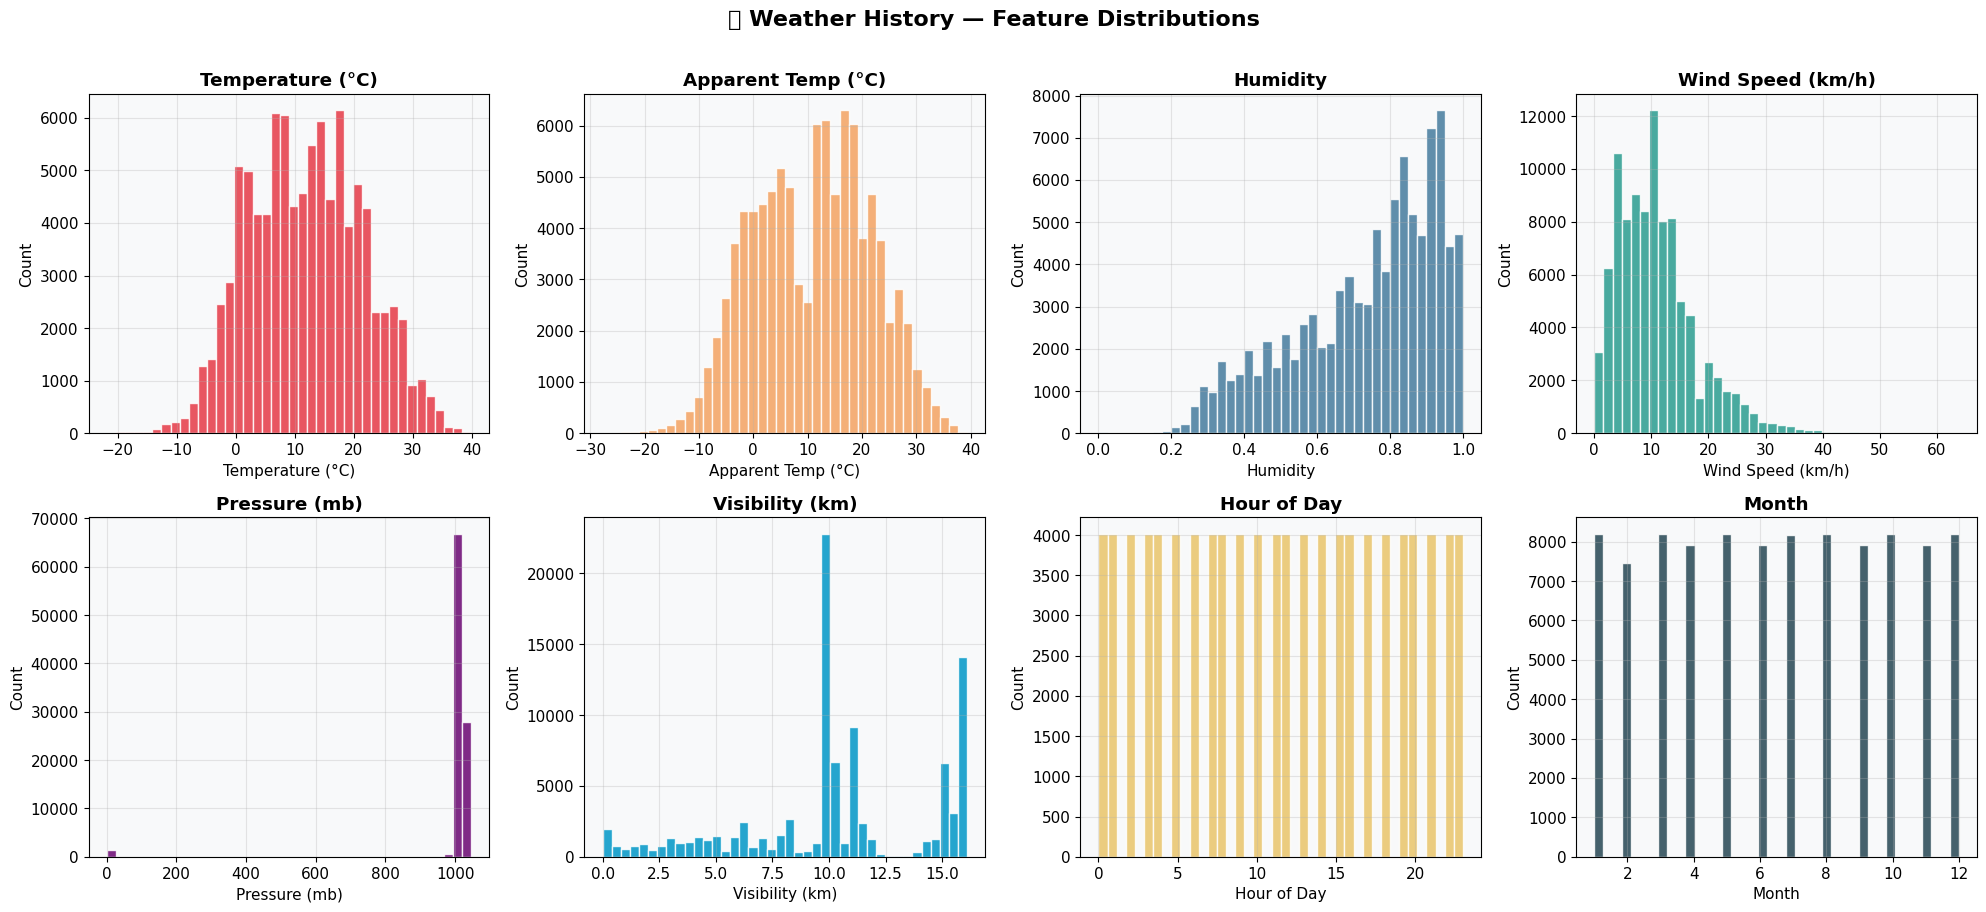

✅ Saved: eda_distributions.png


In [ ]:
# ── Plot 1: Distributions ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
fig.suptitle('🌦️ Weather History — Feature Distributions', fontsize=16, fontweight='bold', y=1.01)

cols   = ['temp_c', 'apparent_temp_c', 'humidity', 'wind_speed',
          'pressure', 'visibility', 'hour', 'month']
colors = ['#E63946','#F4A261','#457B9D','#2A9D8F',
          '#6A0572','#0096C7','#E9C46A','#264653']
labels = ['Temperature (°C)','Apparent Temp (°C)','Humidity','Wind Speed (km/h)',
          'Pressure (mb)','Visibility (km)','Hour of Day','Month']

for ax, col, color, label in zip(axes.flat, cols, colors, labels):
    ax.hist(df[col], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: eda_distributions.png')

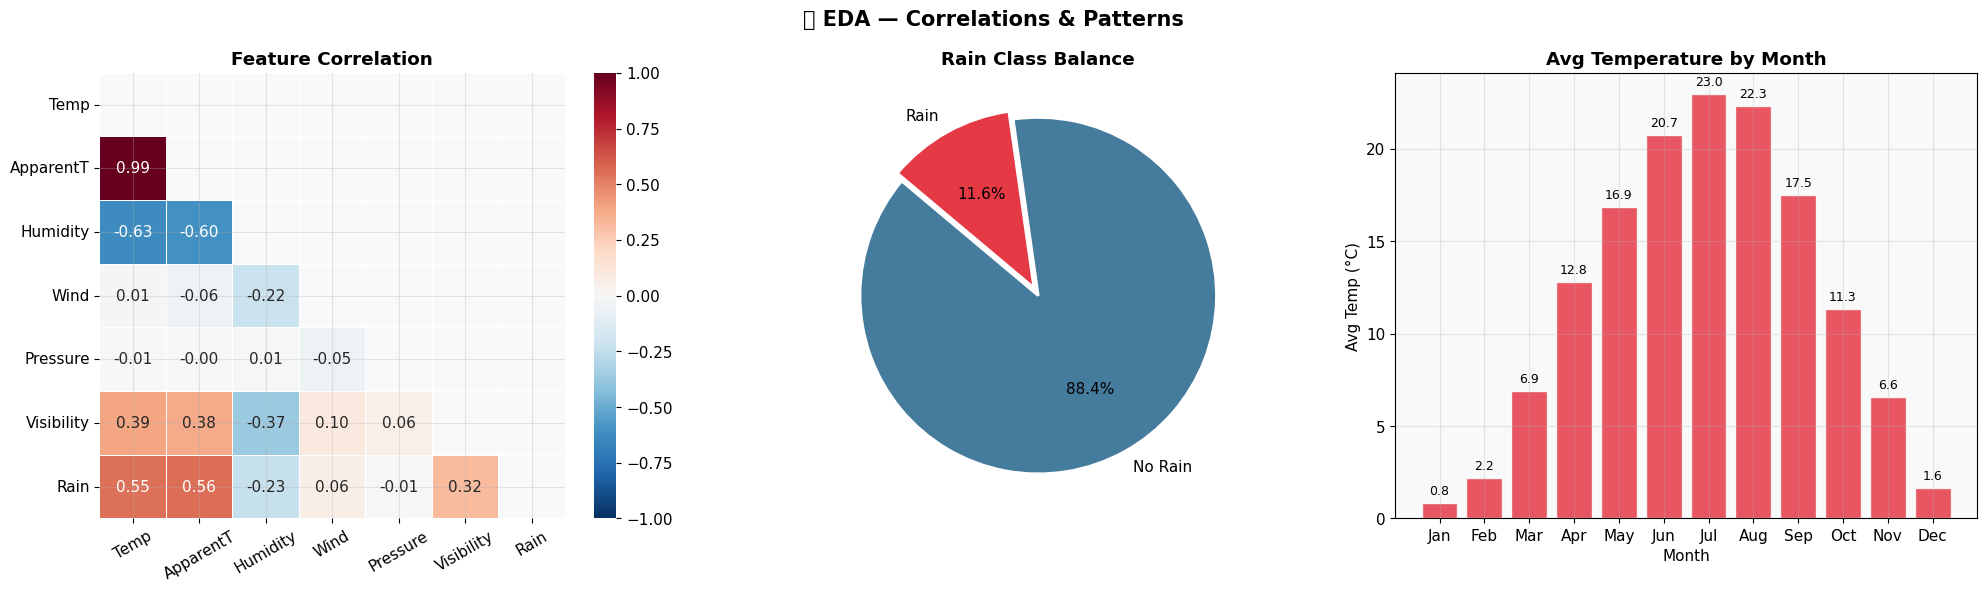

✅ Saved: eda_patterns.png


In [ ]:
# ── Plot 2: Correlation heatmap + Rain balance + Monthly averages ────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('🌦️ EDA — Correlations & Patterns', fontsize=15, fontweight='bold')

# Correlation heatmap
num_cols = ['temp_c','apparent_temp_c','humidity','wind_speed','pressure','visibility','will_rain']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', ax=axes[0],
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            xticklabels=['Temp','ApparentT','Humidity','Wind','Pressure','Visibility','Rain'],
            yticklabels=['Temp','ApparentT','Humidity','Wind','Pressure','Visibility','Rain'])
axes[0].set_title('Feature Correlation', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

# Rain class balance
rain_counts = df['will_rain'].value_counts()
axes[1].pie(rain_counts, labels=['No Rain','Rain'],
            autopct='%1.1f%%', colors=['#457B9D','#E63946'],
            startangle=140, explode=[0, 0.05],
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Rain Class Balance', fontweight='bold')

# Average temperature by month
monthly = df.groupby('month')['temp_c'].mean()
months  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
bars = axes[2].bar(months, monthly.values, color='#E63946', edgecolor='white', alpha=0.85)
axes[2].set_title('Avg Temperature by Month', fontweight='bold')
axes[2].set_xlabel('Month'); axes[2].set_ylabel('Avg Temp (°C)')
for bar, val in zip(bars, monthly.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('eda_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: eda_patterns.png')

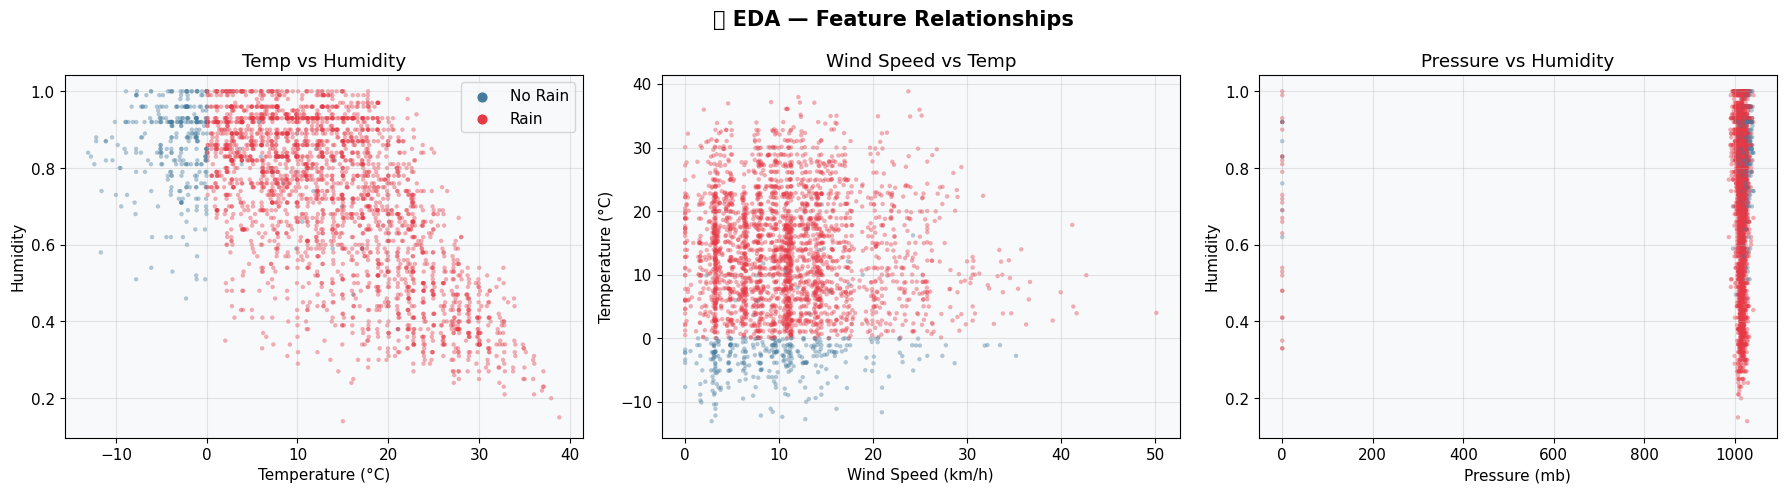

✅ Saved: eda_scatter.png


In [ ]:
# ── Plot 3: Scatter plots between key features ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('🌦️ EDA — Feature Relationships', fontsize=15, fontweight='bold')

sample = df.sample(3000, random_state=42)
colors_scatter = sample['will_rain'].map({0:'#457B9D', 1:'#E63946'})

axes[0].scatter(sample['temp_c'], sample['humidity'],
                c=colors_scatter, alpha=0.4, s=10, edgecolors='none')
axes[0].set_xlabel('Temperature (°C)'); axes[0].set_ylabel('Humidity')
axes[0].set_title('Temp vs Humidity')
for color, label in [('#457B9D','No Rain'),('#E63946','Rain')]:
    axes[0].scatter([], [], c=color, label=label, s=40)
axes[0].legend()

axes[1].scatter(sample['wind_speed'], sample['temp_c'],
                c=colors_scatter, alpha=0.4, s=10, edgecolors='none')
axes[1].set_xlabel('Wind Speed (km/h)'); axes[1].set_ylabel('Temperature (°C)')
axes[1].set_title('Wind Speed vs Temp')

axes[2].scatter(sample['pressure'], sample['humidity'],
                c=colors_scatter, alpha=0.4, s=10, edgecolors='none')
axes[2].set_xlabel('Pressure (mb)'); axes[2].set_ylabel('Humidity')
axes[2].set_title('Pressure vs Humidity')

plt.tight_layout()
plt.savefig('eda_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: eda_scatter.png')

---
## 🌡️ Step 6: Model 1 — Temperature Prediction (Linear Regression)

🌡️  TEMPERATURE PREDICTION — Linear Regression
   MAE           : 0.7427 °C
   RMSE          : 0.9484 °C
   R² (test)     : 0.9902
   R² (5-fold CV): 0.9900


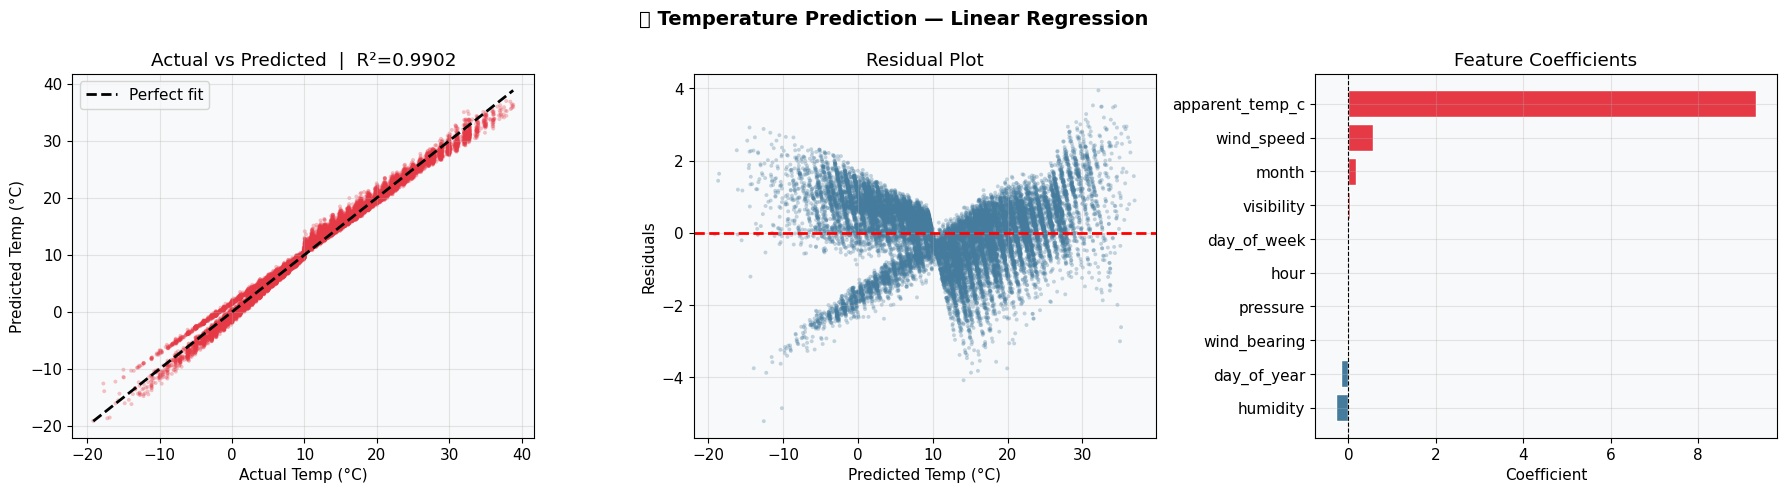

✅ Saved: model1_temperature.png


In [ ]:
# ── Features & Target ────────────────────────────────────────────────────────
TEMP_FEATURES = [
    'apparent_temp_c', 'humidity', 'wind_speed', 'wind_bearing',
    'pressure', 'visibility', 'hour', 'day_of_week', 'month', 'day_of_year'
]
TARGET_TEMP = 'temp_c'

X_temp = df[TEMP_FEATURES]
y_temp = df[TARGET_TEMP]

# ── Scale + Split ─────────────────────────────────────────────────────────────
scaler_temp   = StandardScaler()
X_temp_scaled = scaler_temp.fit_transform(X_temp)
X_tr, X_te, y_tr, y_te = train_test_split(X_temp_scaled, y_temp, test_size=0.2, random_state=42)

# ── Train ─────────────────────────────────────────────────────────────────────
model_temp = LinearRegression()
model_temp.fit(X_tr, y_tr)

# ── Evaluate ──────────────────────────────────────────────────────────────────
y_pred_temp = model_temp.predict(X_te)
mae_t  = mean_absolute_error(y_te, y_pred_temp)
rmse_t = np.sqrt(mean_squared_error(y_te, y_pred_temp))
r2_t   = r2_score(y_te, y_pred_temp)
cv_r2  = cross_val_score(LinearRegression(), X_temp_scaled, y_temp, cv=5, scoring='r2').mean()

print('🌡️  TEMPERATURE PREDICTION — Linear Regression')
print('=' * 46)
print(f'   MAE           : {mae_t:.4f} °C')
print(f'   RMSE          : {rmse_t:.4f} °C')
print(f'   R² (test)     : {r2_t:.4f}')
print(f'   R² (5-fold CV): {cv_r2:.4f}')

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('🌡️ Temperature Prediction — Linear Regression', fontsize=14, fontweight='bold')

# Actual vs Predicted
axes[0].scatter(y_te, y_pred_temp, alpha=0.3, s=8, color='#E63946', edgecolors='none')
lim = [y_te.min(), y_te.max()]
axes[0].plot(lim, lim, 'k--', lw=2, label='Perfect fit')
axes[0].set_xlabel('Actual Temp (°C)'); axes[0].set_ylabel('Predicted Temp (°C)')
axes[0].set_title(f'Actual vs Predicted  |  R²={r2_t:.4f}')
axes[0].legend()

# Residuals
residuals = y_te - y_pred_temp
axes[1].scatter(y_pred_temp, residuals, alpha=0.3, s=8, color='#457B9D', edgecolors='none')
axes[1].axhline(0, color='red', lw=2, linestyle='--')
axes[1].set_xlabel('Predicted Temp (°C)'); axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

# Feature coefficients
coef_temp = pd.Series(model_temp.coef_, index=TEMP_FEATURES).sort_values()
colors_coef = ['#E63946' if c > 0 else '#457B9D' for c in coef_temp]
axes[2].barh(coef_temp.index, coef_temp.values, color=colors_coef, edgecolor='white')
axes[2].axvline(0, color='black', lw=0.8, linestyle='--')
axes[2].set_title('Feature Coefficients'); axes[2].set_xlabel('Coefficient')

plt.tight_layout()
plt.savefig('model1_temperature.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: model1_temperature.png')

---
## 🌧️ Step 7: Model 2 — Rain Prediction (Logistic Regression)

🌧️  RAIN PREDICTION — Logistic Regression
   Accuracy (test)  : 91.44%
   Accuracy (5-fold): 91.76%

              precision    recall  f1-score   support

     No Rain       0.59      0.96      0.73      2300
        Rain       0.99      0.91      0.95     16991

    accuracy                           0.91     19291
   macro avg       0.79      0.93      0.84     19291
weighted avg       0.94      0.91      0.92     19291



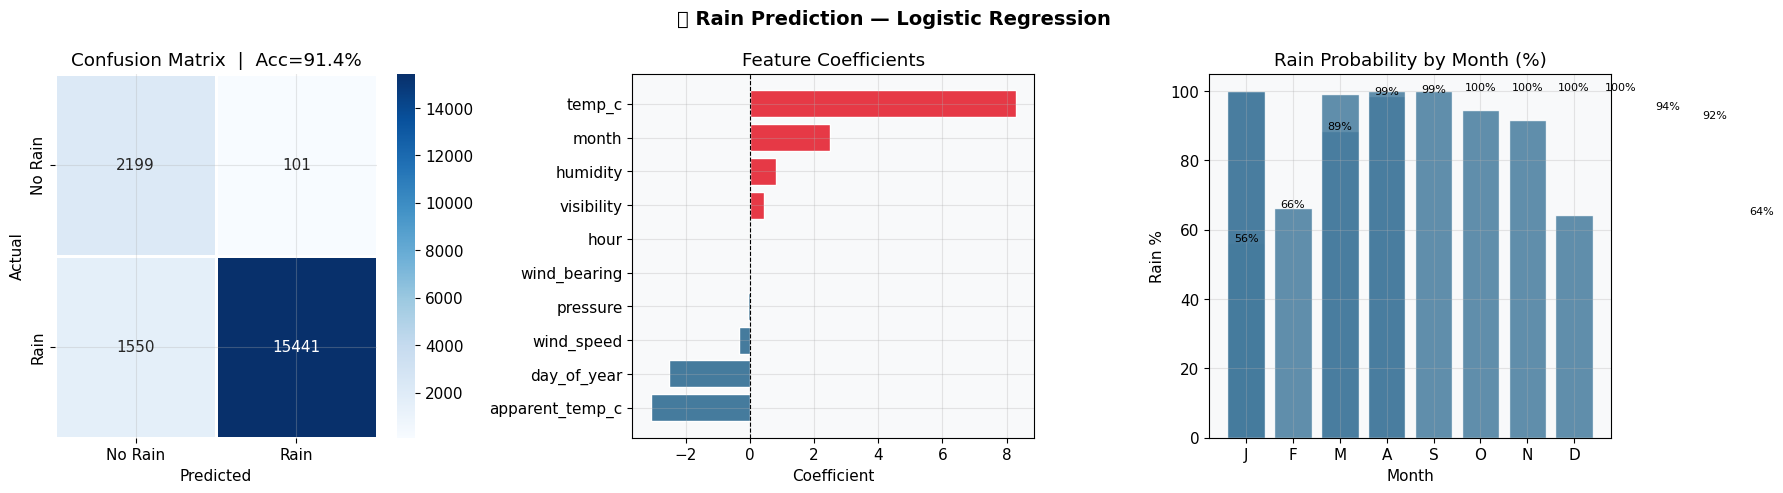

✅ Saved: model2_rain.png


In [ ]:
RAIN_FEATURES = [
    'temp_c', 'apparent_temp_c', 'humidity', 'wind_speed',
    'wind_bearing', 'pressure', 'visibility', 'hour', 'month', 'day_of_year'
]
TARGET_RAIN = 'will_rain'

X_rain = df[RAIN_FEATURES]
y_rain = df[TARGET_RAIN]

scaler_rain   = StandardScaler()
X_rain_scaled = scaler_rain.fit_transform(X_rain)
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_rain_scaled, y_rain, test_size=0.2, random_state=42)

model_rain = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model_rain.fit(X_tr_r, y_tr_r)

y_pred_rain = model_rain.predict(X_te_r)
acc_r  = accuracy_score(y_te_r, y_pred_rain)
cv_acc = cross_val_score(LogisticRegression(max_iter=1000, class_weight='balanced'),
                          X_rain_scaled, y_rain, cv=5, scoring='accuracy').mean()

print('🌧️  RAIN PREDICTION — Logistic Regression')
print('=' * 43)
print(f'   Accuracy (test)  : {acc_r*100:.2f}%')
print(f'   Accuracy (5-fold): {cv_acc*100:.2f}%')
print()
print(classification_report(y_te_r, y_pred_rain, target_names=['No Rain','Rain']))

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('🌧️ Rain Prediction — Logistic Regression', fontsize=14, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_te_r, y_pred_rain)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Rain','Rain'], yticklabels=['No Rain','Rain'],
            linewidths=1, linecolor='white')
axes[0].set_title(f'Confusion Matrix  |  Acc={acc_r*100:.1f}%')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# Feature coefficients
coef_rain = pd.Series(model_rain.coef_[0], index=RAIN_FEATURES).sort_values()
colors_r  = ['#E63946' if c > 0 else '#457B9D' for c in coef_rain]
axes[1].barh(coef_rain.index, coef_rain.values, color=colors_r, edgecolor='white')
axes[1].axvline(0, color='black', lw=0.8, linestyle='--')
axes[1].set_title('Feature Coefficients'); axes[1].set_xlabel('Coefficient')

# Rain by month
monthly_rain = df.groupby('month')['will_rain'].mean() * 100
months_short = ['J','F','M','A','M','J','J','A','S','O','N','D']
axes[2].bar(months_short, monthly_rain.values, color='#457B9D', edgecolor='white', alpha=0.85)
axes[2].set_title('Rain Probability by Month (%)')
axes[2].set_xlabel('Month'); axes[2].set_ylabel('Rain %')
for i, v in enumerate(monthly_rain.values):
    axes[2].text(i, v+0.3, f'{v:.0f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('model2_rain.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: model2_rain.png')

---
## 💧 Step 8: Model 3 — Humidity Prediction (Linear Regression)

💧  HUMIDITY PREDICTION — Linear Regression
   MAE           : 0.1078
   RMSE          : 0.1364
   R² (test)     : 0.5152
   R² (5-fold CV): 0.5095


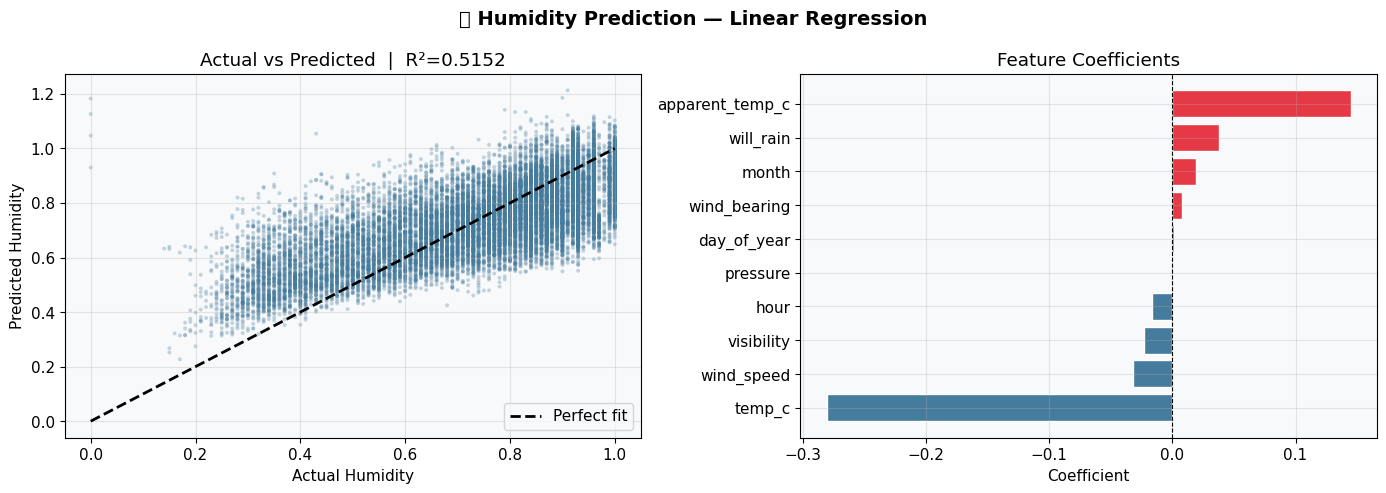

✅ Saved: model3_humidity.png


In [ ]:
HUM_FEATURES = [
    'temp_c', 'apparent_temp_c', 'wind_speed', 'wind_bearing',
    'pressure', 'visibility', 'will_rain', 'hour', 'month', 'day_of_year'
]
TARGET_HUM = 'humidity'

X_hum = df[HUM_FEATURES]
y_hum = df[TARGET_HUM]

scaler_hum   = StandardScaler()
X_hum_scaled = scaler_hum.fit_transform(X_hum)
X_tr_h, X_te_h, y_tr_h, y_te_h = train_test_split(X_hum_scaled, y_hum, test_size=0.2, random_state=42)

model_hum = LinearRegression()
model_hum.fit(X_tr_h, y_tr_h)

y_pred_hum = model_hum.predict(X_te_h)
mae_h  = mean_absolute_error(y_te_h, y_pred_hum)
rmse_h = np.sqrt(mean_squared_error(y_te_h, y_pred_hum))
r2_h   = r2_score(y_te_h, y_pred_hum)
cv_h   = cross_val_score(LinearRegression(), X_hum_scaled, y_hum, cv=5, scoring='r2').mean()

print('💧  HUMIDITY PREDICTION — Linear Regression')
print('=' * 44)
print(f'   MAE           : {mae_h:.4f}')
print(f'   RMSE          : {rmse_h:.4f}')
print(f'   R² (test)     : {r2_h:.4f}')
print(f'   R² (5-fold CV): {cv_h:.4f}')

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('💧 Humidity Prediction — Linear Regression', fontsize=14, fontweight='bold')

axes[0].scatter(y_te_h, y_pred_hum, alpha=0.3, s=8, color='#457B9D', edgecolors='none')
lim = [y_te_h.min(), y_te_h.max()]
axes[0].plot(lim, lim, 'k--', lw=2, label='Perfect fit')
axes[0].set_xlabel('Actual Humidity'); axes[0].set_ylabel('Predicted Humidity')
axes[0].set_title(f'Actual vs Predicted  |  R²={r2_h:.4f}')
axes[0].legend()

coef_hum = pd.Series(model_hum.coef_, index=HUM_FEATURES).sort_values()
colors_h  = ['#E63946' if c > 0 else '#457B9D' for c in coef_hum]
axes[1].barh(coef_hum.index, coef_hum.values, color=colors_h, edgecolor='white')
axes[1].axvline(0, color='black', lw=0.8, linestyle='--')
axes[1].set_title('Feature Coefficients'); axes[1].set_xlabel('Coefficient')

plt.tight_layout()
plt.savefig('model3_humidity.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: model3_humidity.png')

---
## 💨 Step 9: Model 4 — Wind Speed Prediction (Linear Regression)

💨  WIND SPEED PREDICTION — Linear Regression
   MAE           : 4.1037 km/h
   RMSE          : 5.5647 km/h
   R² (test)     : 0.3425
   R² (5-fold CV): 0.3370


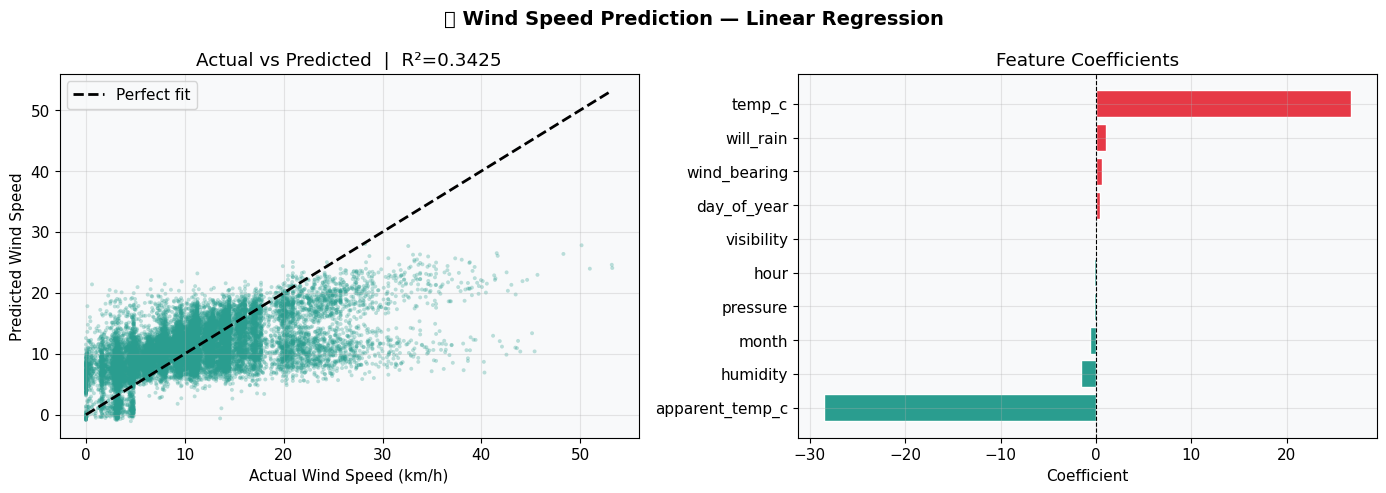

✅ Saved: model4_wind.png


In [ ]:
WIND_FEATURES = [
    'temp_c', 'apparent_temp_c', 'humidity', 'wind_bearing',
    'pressure', 'visibility', 'will_rain', 'hour', 'month', 'day_of_year'
]
TARGET_WIND = 'wind_speed'

X_wind = df[WIND_FEATURES]
y_wind = df[TARGET_WIND]

scaler_wind   = StandardScaler()
X_wind_scaled = scaler_wind.fit_transform(X_wind)
X_tr_w, X_te_w, y_tr_w, y_te_w = train_test_split(X_wind_scaled, y_wind, test_size=0.2, random_state=42)

model_wind = LinearRegression()
model_wind.fit(X_tr_w, y_tr_w)

y_pred_wind = model_wind.predict(X_te_w)
mae_w  = mean_absolute_error(y_te_w, y_pred_wind)
rmse_w = np.sqrt(mean_squared_error(y_te_w, y_pred_wind))
r2_w   = r2_score(y_te_w, y_pred_wind)
cv_w   = cross_val_score(LinearRegression(), X_wind_scaled, y_wind, cv=5, scoring='r2').mean()

print('💨  WIND SPEED PREDICTION — Linear Regression')
print('=' * 46)
print(f'   MAE           : {mae_w:.4f} km/h')
print(f'   RMSE          : {rmse_w:.4f} km/h')
print(f'   R² (test)     : {r2_w:.4f}')
print(f'   R² (5-fold CV): {cv_w:.4f}')

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('💨 Wind Speed Prediction — Linear Regression', fontsize=14, fontweight='bold')

axes[0].scatter(y_te_w, y_pred_wind, alpha=0.3, s=8, color='#2A9D8F', edgecolors='none')
lim = [y_te_w.min(), y_te_w.max()]
axes[0].plot(lim, lim, 'k--', lw=2, label='Perfect fit')
axes[0].set_xlabel('Actual Wind Speed (km/h)'); axes[0].set_ylabel('Predicted Wind Speed')
axes[0].set_title(f'Actual vs Predicted  |  R²={r2_w:.4f}')
axes[0].legend()

coef_wind = pd.Series(model_wind.coef_, index=WIND_FEATURES).sort_values()
colors_w  = ['#E63946' if c > 0 else '#2A9D8F' for c in coef_wind]
axes[1].barh(coef_wind.index, coef_wind.values, color=colors_w, edgecolor='white')
axes[1].axvline(0, color='black', lw=0.8, linestyle='--')
axes[1].set_title('Feature Coefficients'); axes[1].set_xlabel('Coefficient')

plt.tight_layout()
plt.savefig('model4_wind.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: model4_wind.png')

---
## 📋 Step 10: Final Model Performance Summary

In [ ]:
summary = pd.DataFrame({
    'Model'      : ['🌡️ Temperature', '🌧️ Rain', '💧 Humidity', '💨 Wind Speed'],
    'Algorithm'  : ['LinearRegression', 'LogisticRegression', 'LinearRegression', 'LinearRegression'],
    'Target'     : ['temp_c (°C)', 'will_rain (0/1)', 'humidity (0–1)', 'wind_speed (km/h)'],
    'MAE / Error': [f'{mae_t:.4f}°C', f'{(1-acc_r)*100:.2f}%', f'{mae_h:.4f}', f'{mae_w:.4f} km/h'],
    'RMSE'       : [f'{rmse_t:.4f}', 'N/A', f'{rmse_h:.4f}', f'{rmse_w:.4f}'],
    'R² / Accuracy (test)' : [f'{r2_t:.4f}', f'{acc_r*100:.2f}%', f'{r2_h:.4f}', f'{r2_w:.4f}'],
    'R² / Accuracy (CV-5)' : [f'{cv_r2:.4f}', f'{cv_acc*100:.2f}%', f'{cv_h:.4f}', f'{cv_w:.4f}']
})

print('\n📋 ╔══════════════════════════════════════════════╗')
print('   ║        FINAL MODEL PERFORMANCE SUMMARY      ║')
print('   ╚══════════════════════════════════════════════╝\n')
display(summary)

print(f'\n📊 Total training rows used : {len(df):,}')
print(f'📅 Dataset                  : Kaggle — Weather History (Hourly)')
print(f'🔧 Scaler                   : StandardScaler')
print(f'📐 Train / Test split       : 80% / 20%')
print(f'🔄 Cross Validation         : 5-Fold')


📋 ╔══════════════════════════════════════════════╗
   ║        FINAL MODEL PERFORMANCE SUMMARY      ║
   ╚══════════════════════════════════════════════╝



,Model,Algorithm,Target,MAE / Error,RMSE,R² / Accuracy (test),R² / Accuracy (CV-5)
0,🌡️ Temperature,LinearRegression,temp_c (°C),0.7427°C,0.9484,0.9902,0.9900
1,🌧️ Rain,LogisticRegression,will_rain (0/1),8.56%,N/A,91.44%,91.76%
2,💧 Humidity,LinearRegression,humidity (0–1),0.1078,0.1364,0.5152,0.5095
3,💨 Wind Speed,LinearRegression,wind_speed (km/h),4.1037 km/h,5.5647,0.3425,0.3370



📊 Total training rows used : 96,453
📅 Dataset                  : Kaggle — Weather History (Hourly)
🔧 Scaler                   : StandardScaler
📐 Train / Test split       : 80% / 20%
🔄 Cross Validation         : 5-Fold


---
## 📈 Step 11: Visualise All Predictions Together

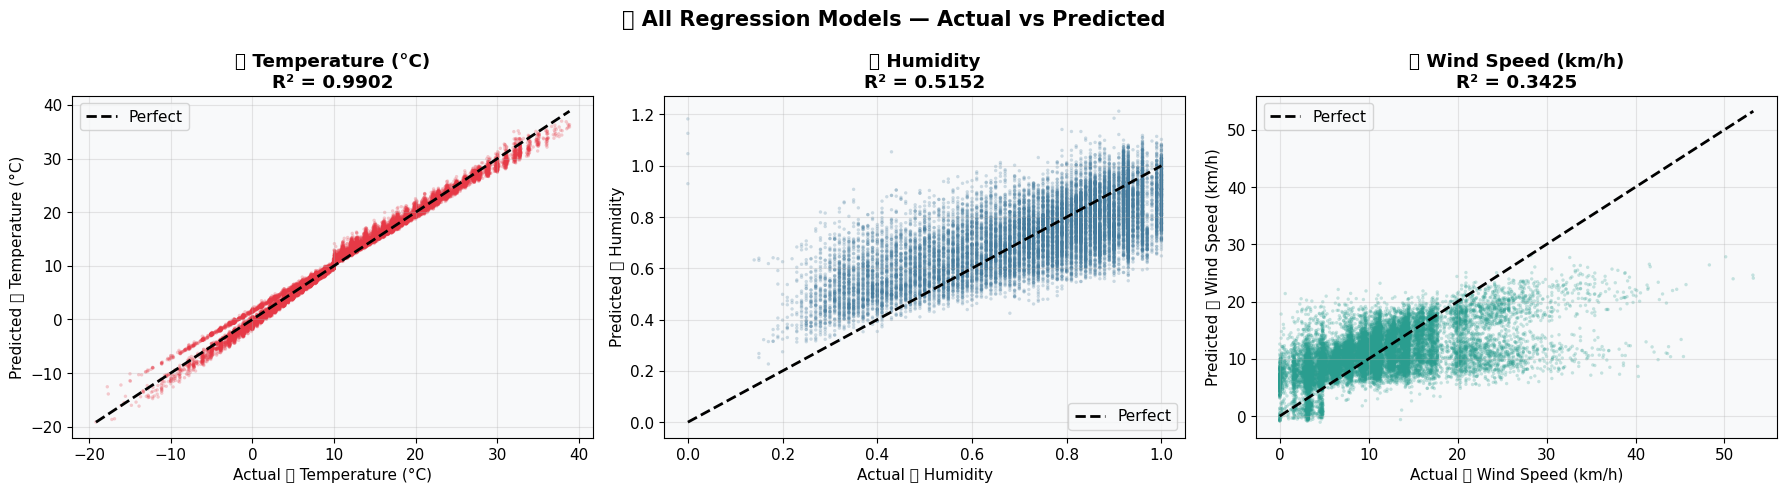

✅ Saved: all_models_comparison.png


In [ ]:
# Side-by-side comparison of all regression models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('📈 All Regression Models — Actual vs Predicted', fontsize=15, fontweight='bold')

models_info = [
    (y_te, y_pred_temp, r2_t, '🌡️ Temperature (°C)', '#E63946'),
    (y_te_h, y_pred_hum, r2_h, '💧 Humidity', '#457B9D'),
    (y_te_w, y_pred_wind, r2_w, '💨 Wind Speed (km/h)', '#2A9D8F'),
]

for ax, (y_true, y_pred, r2, label, color) in zip(axes, models_info):
    ax.scatter(y_true, y_pred, alpha=0.25, s=6, color=color, edgecolors='none')
    lim = [y_true.min(), y_true.max()]
    ax.plot(lim, lim, 'k--', lw=2, label='Perfect')
    ax.set_xlabel(f'Actual {label}'); ax.set_ylabel(f'Predicted {label}')
    ax.set_title(f'{label}\nR² = {r2:.4f}', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: all_models_comparison.png')

---
## 🔮 Step 12: Predict on a Custom Input

In [ ]:
# ── Enter your own values and get predictions ───────────────────────────────
# Change these values to test different weather conditions!

custom_input = {
    'apparent_temp_c' : 22.0,   # Feels-like temperature
    'humidity'        : 0.75,   # 0.0 to 1.0
    'wind_speed'      : 14.0,   # km/h
    'wind_bearing'    : 180,    # degrees
    'pressure'        : 1013.0, # millibars
    'visibility'      : 10.0,   # km
    'hour'            : 14,     # 0–23
    'day_of_week'     : 2,      # 0=Mon, 6=Sun
    'month'           : 6,      # 1–12
    'day_of_year'     : 160     # 1–365
}

# Prepare input frames
inp_temp = pd.DataFrame([{f: custom_input[f] for f in TEMP_FEATURES}])
inp_rain = pd.DataFrame([{f: custom_input.get(f, 25.0) for f in RAIN_FEATURES}])
inp_hum  = pd.DataFrame([{f: custom_input.get(f, 25.0) for f in HUM_FEATURES}])
inp_wind = pd.DataFrame([{f: custom_input.get(f, 25.0) for f in WIND_FEATURES}])

# Fix apparent_temp for rain/hum/wind inputs
for inp in [inp_rain, inp_hum, inp_wind]:
    if 'apparent_temp_c' in inp.columns:
        inp['apparent_temp_c'] = custom_input['apparent_temp_c']
    if 'temp_c' in inp.columns:
        inp['temp_c'] = 25.0
    if 'will_rain' in inp.columns:
        inp['will_rain'] = 0

pred_temp = model_temp.predict(scaler_temp.transform(inp_temp))[0]
pred_rain = model_rain.predict(scaler_rain.transform(inp_rain))[0]
pred_hum  = model_hum.predict(scaler_hum.transform(inp_hum))[0]
pred_wind = model_wind.predict(scaler_wind.transform(inp_wind))[0]

rain_label = '🌧️ YES — Rain expected' if pred_rain == 1 else '☀️ NO — No rain expected'

print('\n🔮 ══════════════════════════════════════════')
print('       CUSTOM PREDICTION RESULTS')
print('   ══════════════════════════════════════════')
print(f'   🌡️  Temperature  : {pred_temp:.2f} °C')
print(f'   🌧️  Rain         : {rain_label}')
print(f'   💧  Humidity     : {pred_hum:.4f}  ({pred_hum*100:.1f}%)')
print(f'   💨  Wind Speed   : {pred_wind:.2f} km/h')
print('   ══════════════════════════════════════════')


🔮 ══════════════════════════════════════════
       CUSTOM PREDICTION RESULTS
   ══════════════════════════════════════════
   🌡️  Temperature  : 21.88 °C
   🌧️  Rain         : 🌧️ YES — Rain expected
   💧  Humidity     : 0.3763  (37.6%)
   💨  Wind Speed   : 14.46 km/h
   ══════════════════════════════════════════


---
## ✅ Project Complete!

### Summary

| Step | Task | Status |
|---|---|---|
| 1 | Install libraries | ✅ |
| 2 | Kaggle API setup | ✅ |
| 3 | Download Weather History dataset | ✅ |
| 4 | Data preprocessing & feature engineering | ✅ |
| 5 | EDA (distributions, correlations, scatter) | ✅ |
| 6 | Temperature — Linear Regression | ✅ |
| 7 | Rain — Logistic Regression | ✅ |
| 8 | Humidity — Linear Regression | ✅ |
| 9 | Wind Speed — Linear Regression | ✅ |
| 10 | Performance summary | ✅ |
| 11 | All models visual comparison | ✅ |
| 12 | Custom input prediction | ✅ |

### Saved output files
- `eda_distributions.png`
- `eda_patterns.png`
- `eda_scatter.png`
- `model1_temperature.png`
- `model2_rain.png`
- `model3_humidity.png`
- `model4_wind.png`
- `all_models_comparison.png`

---
> 💡 **Want better accuracy?** Replace `LinearRegression()` with `RandomForestRegressor(n_estimators=100)` in any model step — it handles non-linear weather patterns much better!